In [6]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
from pathlib import Path
src_path = Path("../src").resolve()
sys.path.insert(0, str(src_path))

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model import GeosteeringHybridModel

%matplotlib inline

Geladenes model.py: C:\Users\ramad\ROGII_Goesteering\src\model.py


In [7]:
# ---------------------------------------------------------------------
# 1. Konfiguration
# ---------------------------------------------------------------------

WINDOW_SIZE = 50
BATCH_SIZE = 256
TEST_WELL_ID = "000d7d20"

MODEL_PATH = Path("../src/models/best_geosteering_model.pth")
DATA_PATH = Path(
    f"../data/test/{TEST_WELL_ID}__horizontal_well.csv"
)

# ---------------------------------------------------------------------
# 2. Gerät auswählen
# ---------------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Verwendetes Gerät: {device}", flush=True)


# ---------------------------------------------------------------------
# 3. Modell laden
# ---------------------------------------------------------------------

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelldatei wurde nicht gefunden: {MODEL_PATH.resolve()}"
    )

model = GeosteeringHybridModel(
    num_features=2,
    window_size=WINDOW_SIZE
)

# weights_only wird von neueren PyTorch-Versionen unterstützt.
try:
    state_dict = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
except TypeError:
    # Fallback für ältere PyTorch-Versionen
    state_dict = torch.load(
        MODEL_PATH,
        map_location=device
    )

model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Modell erfolgreich geladen.", flush=True)


# ---------------------------------------------------------------------
# 4. Testdaten laden
# ---------------------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Testdatei wurde nicht gefunden: {DATA_PATH.resolve()}"
    )

df_test = pd.read_csv(DATA_PATH)

required_columns = {
    "GR",
    "Z",
    "MD",
    "TVT_input"
}

missing_columns = required_columns.difference(df_test.columns)

if missing_columns:
    raise KeyError(
        f"Folgende Spalten fehlen in der CSV-Datei: "
        f"{sorted(missing_columns)}"
    )

print(
    f"Testdaten geladen: {len(df_test)} Zeilen",
    flush=True
)


# ---------------------------------------------------------------------
# 5. Daten bereinigen
# ---------------------------------------------------------------------

numeric_columns = [
    "GR",
    "Z",
    "MD",
    "TVT_input"
]

for column in numeric_columns:
    df_test[column] = pd.to_numeric(
        df_test[column],
        errors="coerce"
    )

# Fehlende GR- und Z-Werte auffüllen
df_test["GR"] = df_test["GR"].ffill().bfill()
df_test["Z"] = df_test["Z"].ffill().bfill()

# MD muss vollständig numerisch sein
if df_test["MD"].isna().any():
    invalid_md_count = int(df_test["MD"].isna().sum())

    raise ValueError(
        f"Die Spalte MD enthält {invalid_md_count} "
        f"nicht numerische oder fehlende Werte."
    )

# GR und Z dürfen nach dem Auffüllen keine NaN-Werte mehr enthalten
if df_test[["GR", "Z"]].isna().any().any():
    raise ValueError(
        "GR oder Z enthält weiterhin NaN-Werte. "
        "Möglicherweise besteht eine komplette Spalte aus NaN."
    )


# ---------------------------------------------------------------------
# 6. Features vorbereiten und skalieren
# ---------------------------------------------------------------------

features = df_test[
    ["GR", "Z"]
].to_numpy(
    dtype=np.float32,
    copy=True
)

# Skalierung wie beim Training
features[:, 0] /= 150.0
features[:, 1] /= 10000.0

if not np.isfinite(features).all():
    raise ValueError(
        "Die Feature-Matrix enthält NaN- oder unendliche Werte."
    )

number_of_windows = len(features) - WINDOW_SIZE + 1

if number_of_windows <= 0:
    raise ValueError(
        f"Der Datensatz enthält nur {len(features)} Zeilen. "
        f"Für WINDOW_SIZE={WINDOW_SIZE} werden mindestens "
        f"{WINDOW_SIZE} Zeilen benötigt."
    )


Verwendetes Gerät: cpu
Modell erfolgreich geladen.
Testdaten geladen: 5278 Zeilen


In [8]:
# ---------------------------------------------------------------------
# 7. Sliding Windows erstellen
# ---------------------------------------------------------------------

# Ergebnisform:
# (Anzahl Fenster, Anzahl Features, Fensterlänge)
#
# In diesem Fall:
# (5229, 2, 50)
windows = np.lib.stride_tricks.sliding_window_view(
    features,
    window_shape=WINDOW_SIZE,
    axis=0
)

# Eigenständiges, zusammenhängendes Array für PyTorch erstellen
windows = np.ascontiguousarray(
    windows,
    dtype=np.float32
)

print(
    f"Fenster erstellt: {windows.shape}",
    flush=True
)


# ---------------------------------------------------------------------
# 8. Modell-Inference in Batches
# ---------------------------------------------------------------------

prediction_batches = []

number_of_batches = int(
    np.ceil(number_of_windows / BATCH_SIZE)
)

print(
    f"Starte Inference für {number_of_windows} Fenster "
    f"in {number_of_batches} Batches.",
    flush=True
)

start_time = time.perf_counter()

with torch.inference_mode():
    for batch_number, start_idx in enumerate(
        range(0, number_of_windows, BATCH_SIZE),
        start=1
    ):
        end_idx = min(
            start_idx + BATCH_SIZE,
            number_of_windows
        )

        x_batch = torch.from_numpy(
            windows[start_idx:end_idx]
        ).to(device)

        model_output = model(x_batch)

        if not isinstance(model_output, torch.Tensor):
            raise TypeError(
                "Das Modell muss einen PyTorch-Tensor zurückgeben. "
                f"Erhaltener Typ: {type(model_output)}"
            )

        # Erwartet wird genau ein Vorhersagewert je Fenster.
        model_output = model_output.reshape(
            x_batch.shape[0],
            -1
        )

        if model_output.shape[1] != 1:
            raise ValueError(
                "Das Modell liefert nicht genau einen Wert je Fenster. "
                f"Ausgabeform: {tuple(model_output.shape)}"
            )

        batch_predictions = (
            model_output[:, 0]
            .detach()
            .cpu()
            .numpy()
        )

        prediction_batches.append(batch_predictions)

        if (
            batch_number == 1
            or batch_number % 5 == 0
            or batch_number == number_of_batches
        ):
            print(
                f"Batch {batch_number}/{number_of_batches} abgeschlossen.",
                flush=True
            )

if device.type == "cuda":
    torch.cuda.synchronize()

inference_duration = time.perf_counter() - start_time

window_predictions = np.concatenate(
    prediction_batches
).astype(np.float64)

if len(window_predictions) != number_of_windows:
    raise RuntimeError(
        "Die Anzahl der Vorhersagen entspricht nicht "
        "der Anzahl der Fenster."
    )

print(
    f"Inference beendet nach {inference_duration:.2f} Sekunden.",
    flush=True
)

# ---------------------------------------------------------------------
# 9. Vorhersagen dem DataFrame zuordnen
# ---------------------------------------------------------------------

predictions = np.full(
    len(df_test),
    np.nan,
    dtype=np.float64
)

# Die erste Vorhersage gehört zum letzten Element des ersten Fensters,
# also zu Position WINDOW_SIZE - 1.
predictions[WINDOW_SIZE - 1:] = window_predictions

df_test["TVT_pred"] = predictions

print(
    "Vorhersagen erfolgreich in den DataFrame geschrieben.",
    flush=True
)


# ---------------------------------------------------------------------
# 10. Plot-Daten als NumPy-Arrays vorbereiten
# ---------------------------------------------------------------------

md = df_test["MD"].to_numpy(
    dtype=np.float64
)

tvt_input = df_test["TVT_input"].to_numpy(
    dtype=np.float64
)

tvt_pred = df_test["TVT_pred"].to_numpy(
    dtype=np.float64
)

valid_md = np.isfinite(md)
valid_input = valid_md & np.isfinite(tvt_input)
valid_prediction = valid_md & np.isfinite(tvt_pred)

if not valid_md.any():
    raise ValueError(
        "MD enthält keine gültigen numerischen Werte."
    )

if not valid_prediction.any():
    raise ValueError(
        "Es wurden keine gültigen Vorhersagen erzeugt."
    )

md_min = float(np.min(md[valid_md]))
md_max = float(np.max(md[valid_md]))

print("Datentypen:")
print(df_test[["MD", "TVT_input", "TVT_pred"]].dtypes)
print(f"Anzahl Zeilen: {len(df_test)}")
print(f"MD NaN: {np.isnan(md).sum()}")
print(f"MD inf: {np.isinf(md).sum()}")
print(f"MD Minimum: {md_min}")
print(f"MD Maximum: {md_max}")

Fenster erstellt: (5229, 2, 50)
Starte Inference für 5229 Fenster in 21 Batches.
Batch 1/21 abgeschlossen.
Batch 5/21 abgeschlossen.
Batch 10/21 abgeschlossen.
Batch 15/21 abgeschlossen.
Batch 20/21 abgeschlossen.
Batch 21/21 abgeschlossen.
Inference beendet nach 0.06 Sekunden.
Vorhersagen erfolgreich in den DataFrame geschrieben.
Datentypen:
MD           float64
TVT_input    float64
TVT_pred     float64
dtype: object
Anzahl Zeilen: 5278
MD NaN: 0
MD inf: 0
MD Minimum: 11467.0
MD Maximum: 16744.0


In [9]:
# ---------------------------------------------------------------------
# 11. Beginn des Evaluationsbereichs bestimmen
# ---------------------------------------------------------------------

missing_input_positions = np.flatnonzero(
    ~np.isfinite(tvt_input)
)

if missing_input_positions.size > 0:
    evaluation_start_position = int(
        missing_input_positions[0]
    )

    if not np.isfinite(md[evaluation_start_position]):
        raise ValueError(
            "Am Beginn des Evaluationsbereichs ist MD ungültig."
        )

    evaluation_start_md = float(
        md[evaluation_start_position]
    )

    print(
        f"Evaluationsbereich: "
        f"Start={evaluation_start_md}, Ende={md_max}",
        flush=True
    )
else:
    evaluation_start_md = None

    print(
        "TVT_input enthält keinen fehlenden Bereich.",
        flush=True
    )


# ---------------------------------------------------------------------
# 12. Grenzen der Y-Achse bestimmen
# ---------------------------------------------------------------------

valid_y_values = []

if valid_input.any():
    valid_y_values.append(
        tvt_input[valid_input]
    )

if valid_prediction.any():
    valid_y_values.append(
        tvt_pred[valid_prediction]
    )

all_y = np.concatenate(valid_y_values)

y_min = float(np.min(all_y))
y_max = float(np.max(all_y))

y_range = y_max - y_min
y_padding = max(y_range * 0.05, 1e-6)

plot_y_min = y_min - y_padding
plot_y_max = y_max + y_padding


Evaluationsbereich: Start=12909.0, Ende=16744.0


In [10]:
evaluation_mask = (
    np.isfinite(tvt_input)
    & np.isfinite(tvt_pred)
)

y_true = tvt_input[evaluation_mask]
y_pred = tvt_pred[evaluation_mask]

print("--- Ground Truth ---")
print("Anzahl:", len(y_true))
print("Mittelwert:", np.mean(y_true))
print("Median:", np.median(y_true))
print("Standardabweichung:", np.std(y_true))
print("Minimum:", np.min(y_true))
print("Maximum:", np.max(y_true))

print("\n--- Prediction ---")
print("Mittelwert:", np.mean(y_pred))
print("Standardabweichung:", np.std(y_pred))
print("Minimum:", np.min(y_pred))
print("Maximum:", np.max(y_pred))

print(
    "\nStreuungsverhältnis Prediction/Target:",
    np.std(y_pred) / np.std(y_true)
)



from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mean_prediction = np.full_like(
    y_true,
    np.mean(y_true)
)

print("--- Modell ---")
print("MAE:", mean_absolute_error(y_true, y_pred))
print(
    "RMSE:",
    mean_squared_error(y_true, y_pred) ** 0.5
)
print("R²:", r2_score(y_true, y_pred))

print("\n--- Konstante Mittelwert-Baseline ---")
print(
    "MAE:",
    mean_absolute_error(y_true, mean_prediction)
)
print(
    "RMSE:",
    mean_squared_error(y_true, mean_prediction) ** 0.5
)

--- Ground Truth ---
Anzahl: 1393
Mittelwert: 11659.987315147164
Median: 11746.03
Standardabweichung: 132.28679918817843
Minimum: 11285.88
Maximum: 11756.12

--- Prediction ---
Mittelwert: 3908.1892620889043
Standardabweichung: 0.0003908994416252764
Minimum: 3908.1875
Maximum: 3908.189697265625

Streuungsverhältnis Prediction/Target: 2.9549391475503204e-06
--- Modell ---
MAE: 7751.79805305826
RMSE: 7752.9267275277025
R²: -3433.7753873913284

--- Konstante Mittelwert-Baseline ---
MAE: 108.77088732556254
RMSE: 132.28679918817843



--- Diagnose TVT_pred ---
Anzahl gültiger Werte: 5229
Form X: (5229,)
Form Y: (5229,)
Minimum: 3908.1875
Maximum: 3908.189697265625
Mittelwert: 3908.189374966383
Median: 3908.189453125
Perzentile: [3908.1875     3908.18798828 3908.18945312 3908.18945312 3908.18945312
 3908.18969727 3908.18969727]
Größter Absolutwert: 3908.189697265625
MD monoton steigend: True
Erste Vorhersagen: [3908.18945312 3908.18945312 3908.18945312 3908.18945312 3908.18945312
 3908.18945312 3908.18945312 3908.18945312 3908.18945312 3908.18945312]
Vor Figure-Erstellung
Figure erstellt
TVT_input gezeichnet
Vorhersage gezeichnet
Zezeichne Evaluationsgrenze
Evaluationsgrenze fertig
Titel fertig
Achsenbeschriftung fertig
Grid fertig
Legende fertig
Plot-Code vollständig durchlaufen
Gespeichert


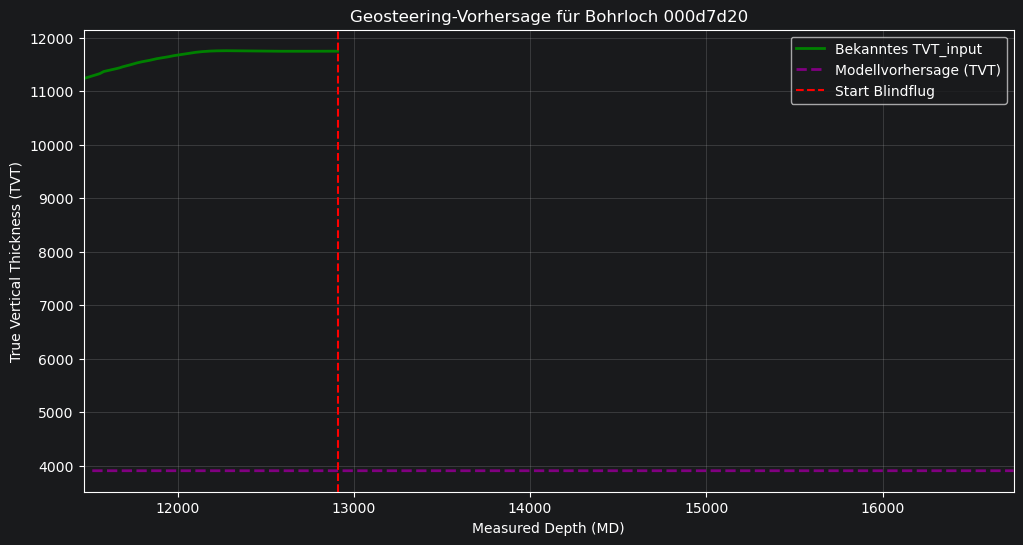

In [11]:
# ---------------------------------------------------------------------
# 13. Interaktiven Plot erstellen
# ---------------------------------------------------------------------

#-----------------------------------------------------------------------
prediction_x = md[valid_prediction]
prediction_y = tvt_pred[valid_prediction]

print("\n--- Diagnose TVT_pred ---", flush=True)
print("Anzahl gültiger Werte:", len(prediction_y), flush=True)
print("Form X:", prediction_x.shape, flush=True)
print("Form Y:", prediction_y.shape, flush=True)
print("Minimum:", np.min(prediction_y), flush=True)
print("Maximum:", np.max(prediction_y), flush=True)
print("Mittelwert:", np.mean(prediction_y), flush=True)
print("Median:", np.median(prediction_y), flush=True)
print(
    "Perzentile:",
    np.percentile(prediction_y, [0, 1, 25, 50, 75, 99, 100]),
    flush=True
)
print(
    "Größter Absolutwert:",
    np.max(np.abs(prediction_y)),
    flush=True
)
print(
    "MD monoton steigend:",
    np.all(np.diff(prediction_x) >= 0),
    flush=True
)
print(
    "Erste Vorhersagen:",
    prediction_y[:10],
    flush=True
)
#--------------------------------------------------------------------------------

# Alte, noch geöffnete Figures schließen
print("Vor Figure-Erstellung", flush=True)

fig, ax = plt.subplots(figsize=(12, 6))

print("Figure erstellt", flush=True)

ax.plot(
    md[valid_input],
    tvt_input[valid_input],
    color="green",
    linewidth=2,
    label="Bekanntes TVT_input"
)

print("TVT_input gezeichnet", flush=True)

ax.plot(
    md[valid_prediction],
    tvt_pred[valid_prediction],
    color="purple",
    linestyle="--",
    linewidth=2,
    label="Modellvorhersage (TVT)"
)

print("Vorhersage gezeichnet", flush=True)

ax.set_xlim(md_min, md_max)
ax.set_ylim(plot_y_min, plot_y_max)

print("Zezeichne Evaluationsgrenze", flush=True)

if evaluation_start_md is not None:
    ax.plot(
        [evaluation_start_md, evaluation_start_md],
        [plot_y_min, plot_y_max],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Start Blindflug",
        scalex=False,
        scaley=False
    )

print("Evaluationsgrenze fertig", flush=True)

ax.set_title(
    f"Geosteering-Vorhersage für Bohrloch {TEST_WELL_ID}"
)
print("Titel fertig", flush=True)

ax.set_xlabel("Measured Depth (MD)")
ax.set_ylabel("True Vertical Thickness (TVT)")
print("Achsenbeschriftung fertig", flush=True)

ax.grid(True, alpha=0.3)
print("Grid fertig", flush=True)

ax.legend()
print("Legende fertig", flush=True)

print("Plot-Code vollständig durchlaufen", flush=True)


output_path = Path(f"inference_plot_{TEST_WELL_ID}.png")


fig.savefig(output_path, bbox_inches="tight")
print("Gespeichert")

plt.show()